In [2]:
import dython
from dython.nominal import associations
import pandas as pd

In [3]:
path = r"C:\Users\tvlan\Downloads\housing_mnar_500.csv"

df = pd.read_csv(path)

for i in df.columns:
    print(df[i].dtype)



object
object
object
int64
int64
int64
int64
int64
float64
int64
float64
float64
float64
object
float64


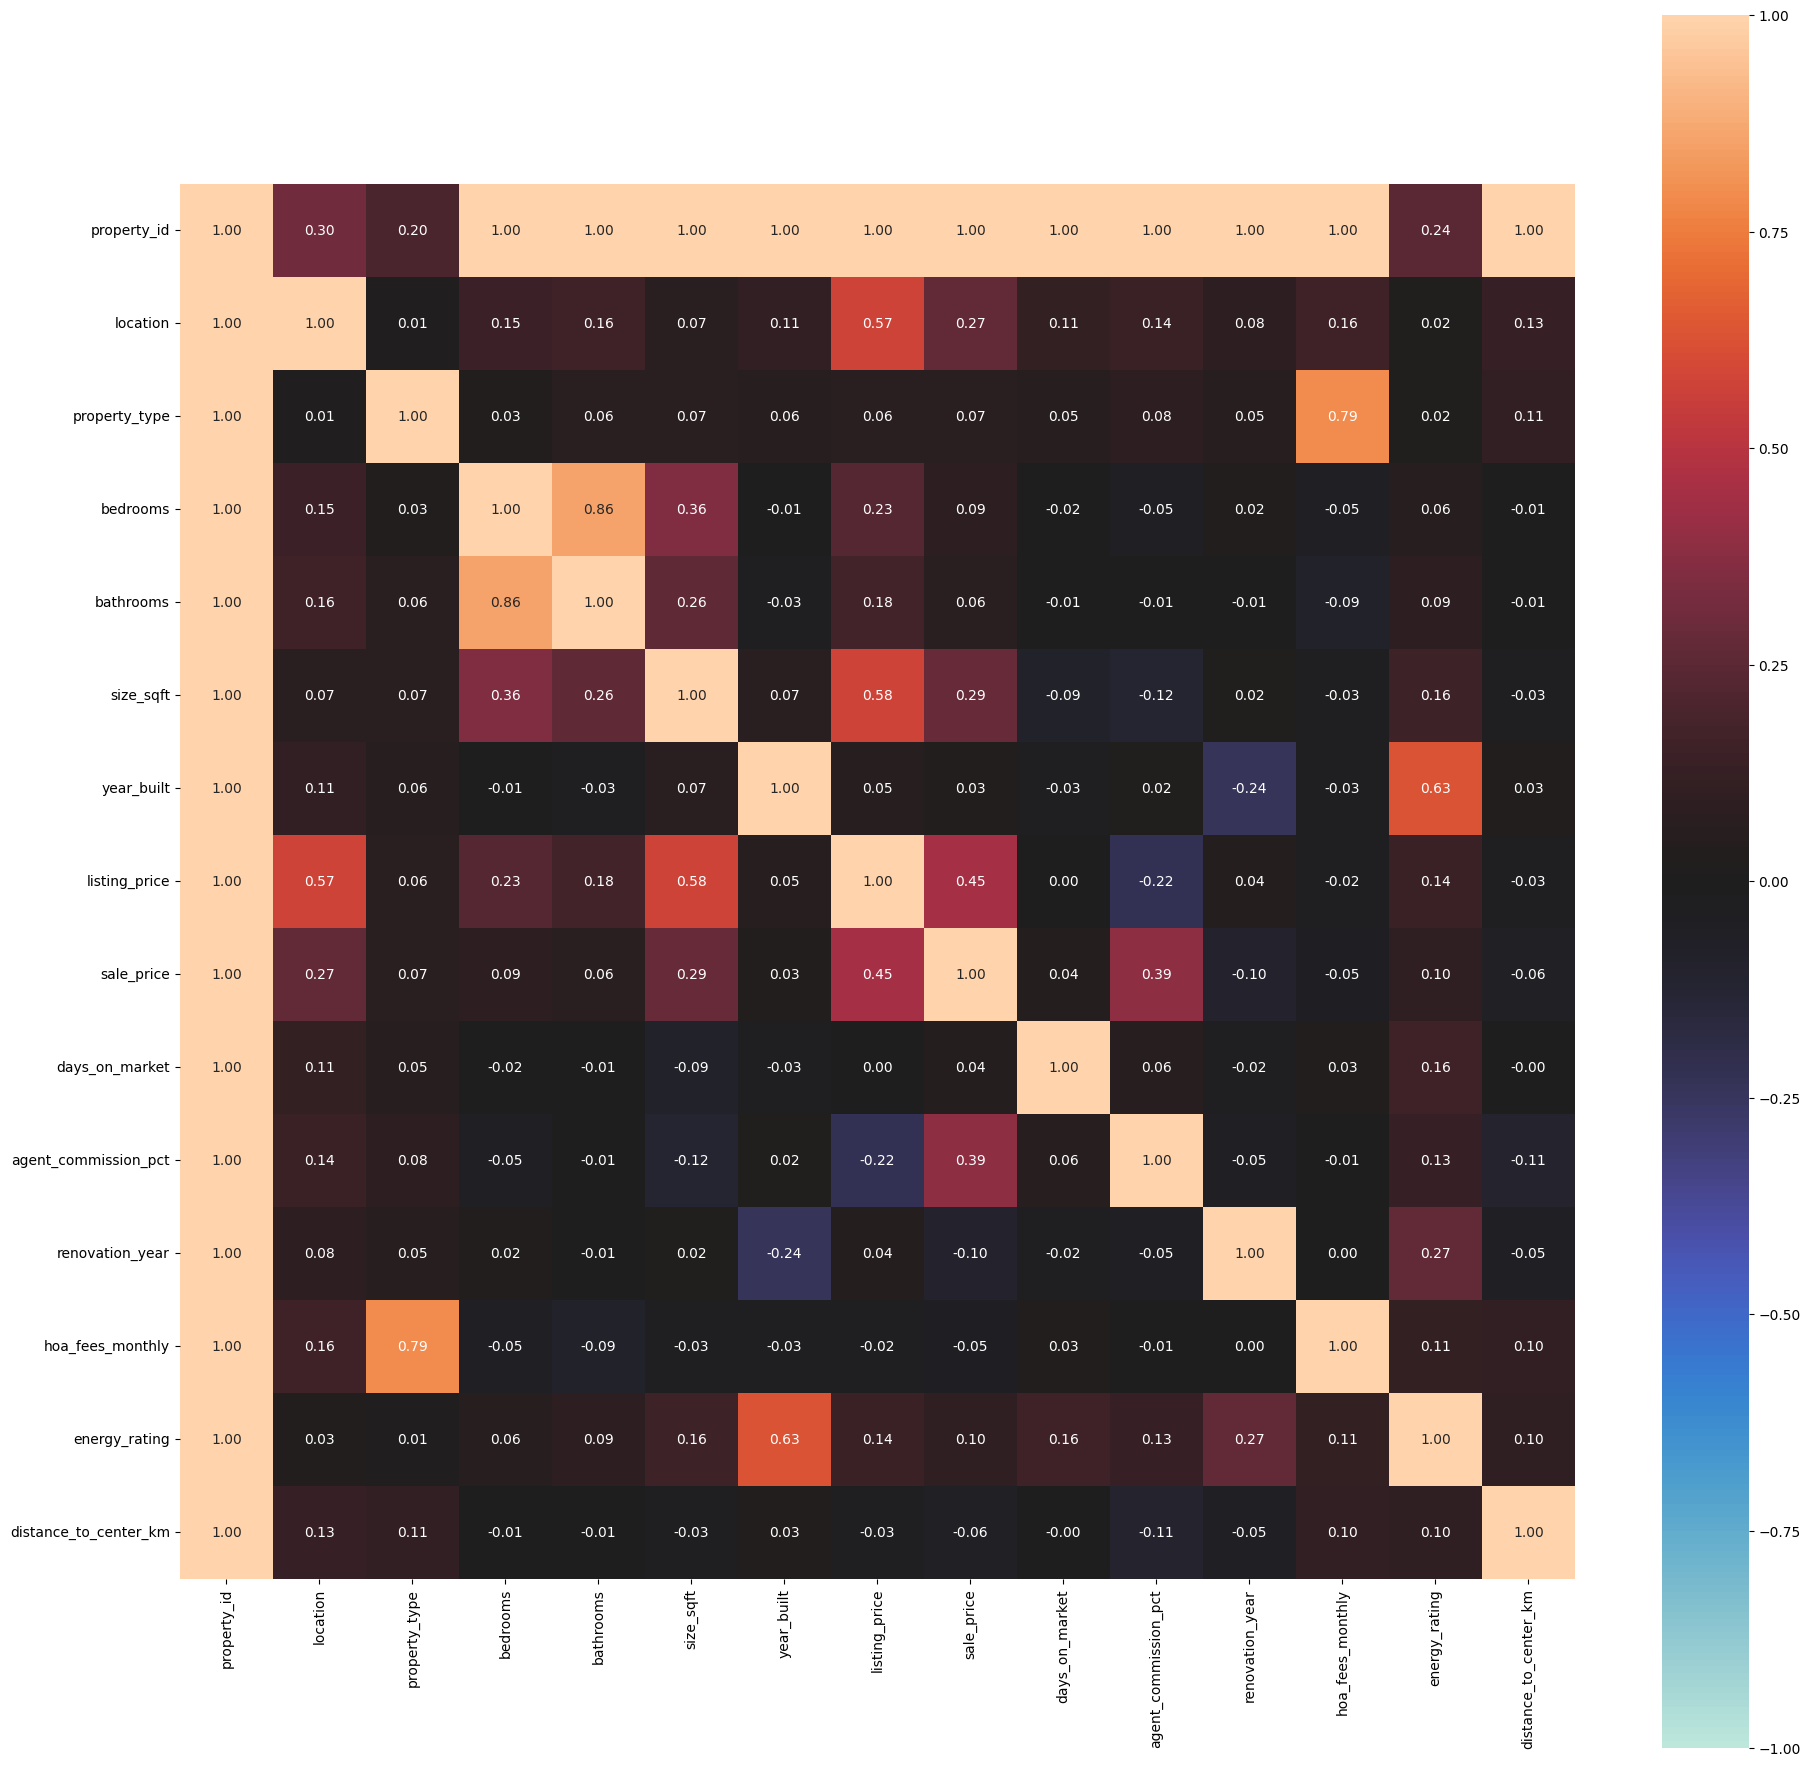

property_id              1.000000
distance_to_center_km    1.000000
location                 0.126516
property_type            0.105153
hoa_fees_monthly         0.104495
energy_rating            0.096335
year_built               0.025019
days_on_market          -0.001305
bathrooms               -0.005787
bedrooms                -0.010873
listing_price           -0.027538
size_sqft               -0.034500
renovation_year         -0.052834
sale_price              -0.057098
agent_commission_pct    -0.108664
Name: distance_to_center_km, dtype: float64

In [4]:

target_feature = "distance_to_center_km"

def correlation_tool(df,target_feature,excluded = []):
 
    if excluded != None:
     df = df.drop(columns= excluded)

    results = associations(
            df,
            nominal_columns='auto',
            nom_nom_assoc='theil'  # detects categorical cols; rest treated as numerical
        )

    target_assoc = results['corr'][target_feature].sort_values(ascending=False)
    
    return target_assoc

correlation_tool(df,target_feature = target_feature)

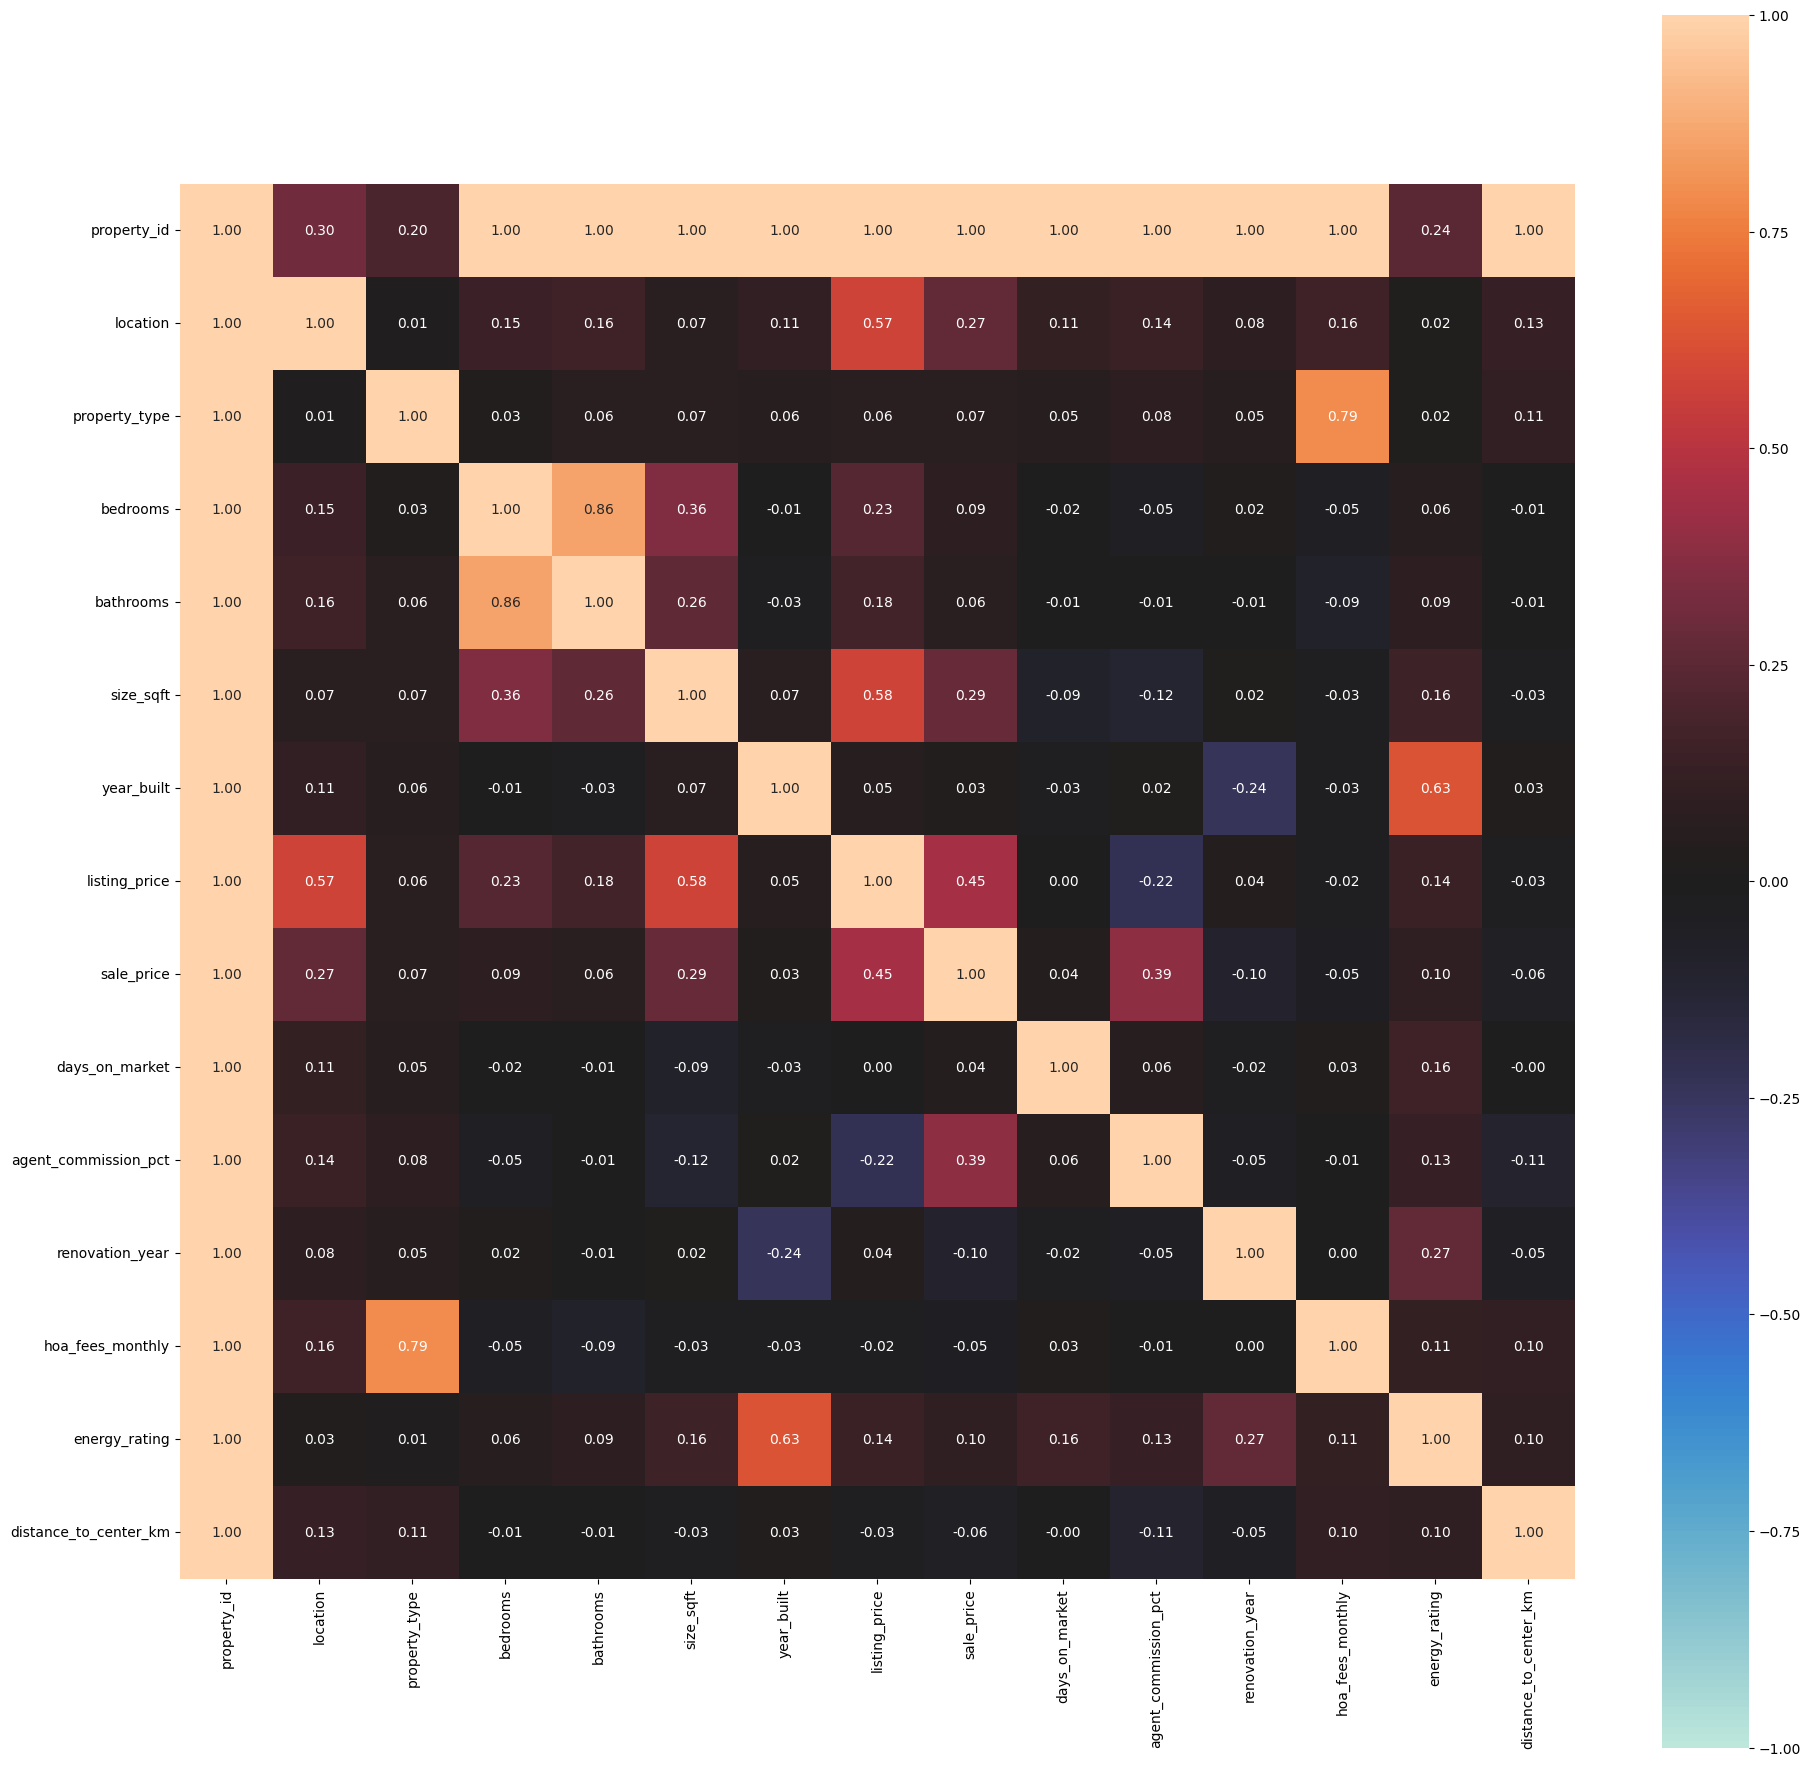

property_id              1.000000
distance_to_center_km    1.000000
location                 0.126516
property_type            0.105153
hoa_fees_monthly         0.104495
energy_rating            0.096335
year_built               0.025019
days_on_market          -0.001305
bathrooms               -0.005787
bedrooms                -0.010873
listing_price           -0.027538
size_sqft               -0.034500
renovation_year         -0.052834
sale_price              -0.057098
agent_commission_pct    -0.108664
Name: distance_to_center_km, dtype: float64

In [5]:

target_feature = "distance_to_center_km"

def correlation_tool(df,target_feature,excluded = []):

    if excluded != None:
     df = df.drop(columns= excluded)

    results = associations(
            df,
            nominal_columns='auto',
            nom_nom_assoc='theil'  # detects categorical cols; rest treated as numerical
        )

    target_assoc = results['corr'][target_feature].sort_values(ascending=False)
    
    return target_assoc

correlation_tool(df,target_feature = target_feature)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from pathlib import Path
from datetime import datetime

now = datetime.now()

def one_hot_encoding(path,target,columns_drop = None):
    
    now = datetime.now()

    df1 = pd.read_csv(path)
    
    if columns_drop is None:
            columns_drop = []

    df = df1.drop(columns = columns_drop).copy()

    path_name = Path(path)

    encoder = OneHotEncoder(sparse_output = False, drop = "if_binary", handle_unknown = "ignore")

    X_encoded = encoder.fit_transform(df)
    

    X_encoded = pd.DataFrame(X_encoded , columns = encoder.get_feature_names_out(df.columns))

    Encoded_merged = pd.concat([X_encoded , df1[target]] , axis = 1)

    now = datetime.now()

    timestamp1 = now.strftime("%Y%m%d_%H%M%S")

    output_path  = path_name.parent/ f"{path_name.stem}_{timestamp1}.csv"

    Encoded_merged.to_csv(output_path,encoding="utf-8",index= False)
        
    return output_path

In [31]:
target_feature = "sepsis_risk"
path = r"C:/Users/tvlan/Downloads/early_sepsis_full_simulated_dataset_dropped_20260602_205925_encoded_20260602_205927.csv"

df = pd.read_csv(path)


one_hot_encoding(path,target_feature)

C:\Users\tvlan\Downloads
early_sepsis_full_simulated_dataset_dropped_20260602_205925_encoded_20260602_205927


WindowsPath('C:/Users/tvlan/Downloads/early_sepsis_full_simulated_dataset_dropped_20260602_205925_encoded_20260602_205927_20260602_210055.csv')